In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import StandardScaler

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Load dataset with features
df = pd.read_csv("/content/drive/MyDrive/FactLens_Group9/data/df_with_features.csv")

# Load TF-IDF matrix and vectorizer
X_tfidf = sp.load_npz("/content/drive/MyDrive/FactLens_Group9/data/tfidf_matrix.npz")

with open("/content/drive/MyDrive/FactLens_Group9/data/tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

print(f"Dataset loaded: {len(df)} articles")
print(f"TF-IDF matrix: {X_tfidf.shape}")
print(f"\nLabel distribution:")
print(df["label"].value_counts())

Dataset loaded: 38590 articles
TF-IDF matrix: (38590, 50000)

Label distribution:
label
REAL    21191
FAKE    17399
Name: count, dtype: int64


In [4]:
# Select only the 5 useful features - dropping caps_ratio
extra_features = df[[
    "sentiment",
    "subjectivity",
    "readability",
    "exclamation_count",
    "question_count"
]].values

print(f"Extra features matrix shape: {extra_features.shape}")
print(f"Features included: sentiment, subjectivity, readability, exclamation_count, question_count")

# Check for any missing values in features
print(f"\nMissing values in features: {pd.DataFrame(extra_features).isnull().sum().sum()}")

Extra features matrix shape: (38590, 5)
Features included: sentiment, subjectivity, readability, exclamation_count, question_count

Missing values in features: 0


In [5]:
# Scale features to same range as TF-IDF values
# This prevents large readability scores from dominating
scaler = StandardScaler()
extra_features_scaled = scaler.fit_transform(extra_features)

print("Features scaled successfully")
print(f"\nBefore scaling — readability mean: {extra_features[:, 2].mean():.2f}")
print(f"After scaling  — readability mean: {extra_features_scaled[:, 2].mean():.4f}")

# Save scaler for later use
with open("/content/drive/MyDrive/FactLens_Group9/data/feature_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("\nScaler saved successfully")

Features scaled successfully

Before scaling — readability mean: 46.84
After scaling  — readability mean: 0.0000

Scaler saved successfully


In [6]:
# Convert scaled features to sparse matrix
extra_sparse = sp.csr_matrix(extra_features_scaled)

# Combine TF-IDF matrix with extra features horizontally
X_combined = sp.hstack([X_tfidf, extra_sparse])

print(f"TF-IDF matrix shape:        {X_tfidf.shape}")
print(f"Extra features shape:       {extra_sparse.shape}")
print(f"Combined matrix shape:      {X_combined.shape}")
print(f"\nExtra columns added: {X_combined.shape[1] - X_tfidf.shape[1]}")

TF-IDF matrix shape:        (38590, 50000)
Extra features shape:       (38590, 5)
Combined matrix shape:      (38590, 50005)

Extra columns added: 5


In [7]:
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} articles")
print(f"Test set:     {X_test.shape[0]} articles")
print(f"\nTraining label distribution:")
print(y_train.value_counts())

Training set: 30872 articles
Test set:     7718 articles

Training label distribution:
label
REAL    16953
FAKE    13919
Name: count, dtype: int64


In [8]:
print("Training enhanced Logistic Regression model...")
print("This will take 2-3 minutes...")

model_enhanced = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42,
    class_weight="balanced",
    solver="lbfgs",
    n_jobs=-1
)

model_enhanced.fit(X_train, y_train)

print("Training complete")

Training enhanced Logistic Regression model...
This will take 2-3 minutes...
Training complete


In [9]:
y_pred = model_enhanced.predict(X_test)
y_prob = model_enhanced.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Enhanced Model Accuracy: {accuracy:.4f} ({accuracy:.2%})")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

Enhanced Model Accuracy: 0.9833 (98.33%)

Detailed Classification Report:
              precision    recall  f1-score   support

        FAKE       0.99      0.98      0.98      3480
        REAL       0.98      0.99      0.98      4238

    accuracy                           0.98      7718
   macro avg       0.98      0.98      0.98      7718
weighted avg       0.98      0.98      0.98      7718



In [10]:
original_accuracy = 0.9852
enhanced_accuracy = accuracy
difference = enhanced_accuracy - original_accuracy

print("=" * 55)
print("COMPARISON — ORIGINAL vs ENHANCED MODEL")
print("=" * 55)
print(f"Original model (TF-IDF only):     98.52%")
print(f"Debiased model (TF-IDF only):     97.50%")
print(f"Enhanced model (TF-IDF + features): {enhanced_accuracy:.2%}")
print(f"\nImprovement over original:        {difference:+.2%}")
print("=" * 55)

if difference > 0.01:
    print("\n✓ Features improved the model meaningfully")
elif difference > 0:
    print("\n✓ Features improved the model slightly")
elif difference > -0.01:
    print("\n~ Features had minimal impact")
else:
    print("\n✗ Features hurt the model — TF-IDF alone was better")

COMPARISON — ORIGINAL vs ENHANCED MODEL
Original model (TF-IDF only):     98.52%
Debiased model (TF-IDF only):     97.50%
Enhanced model (TF-IDF + features): 98.33%

Improvement over original:        -0.19%

~ Features had minimal impact


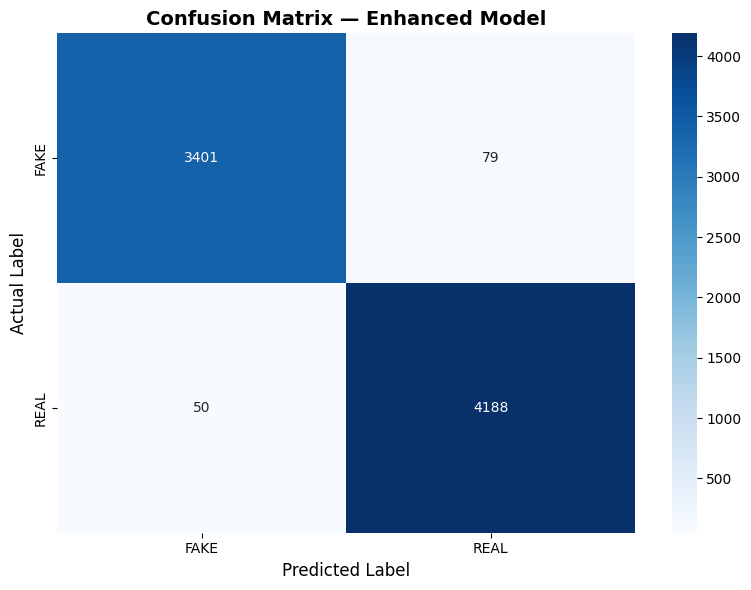


Breakdown:
  Correctly identified FAKE:          4,188
  Correctly identified REAL:          3,401
  FAKE incorrectly called REAL:       50
  REAL incorrectly called FAKE:       79


In [11]:
cm = confusion_matrix(y_test, y_pred, labels=["FAKE", "REAL"])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["FAKE", "REAL"],
            yticklabels=["FAKE", "REAL"])
plt.title("Confusion Matrix — Enhanced Model",
          fontsize=14, fontweight="bold")
plt.ylabel("Actual Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FactLens_Group9/data/confusion_matrix_enhanced.png",
            dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nBreakdown:")
print(f"  Correctly identified FAKE:          {tp:,}")
print(f"  Correctly identified REAL:          {tn:,}")
print(f"  FAKE incorrectly called REAL:       {fn:,}")
print(f"  REAL incorrectly called FAKE:       {fp:,}")

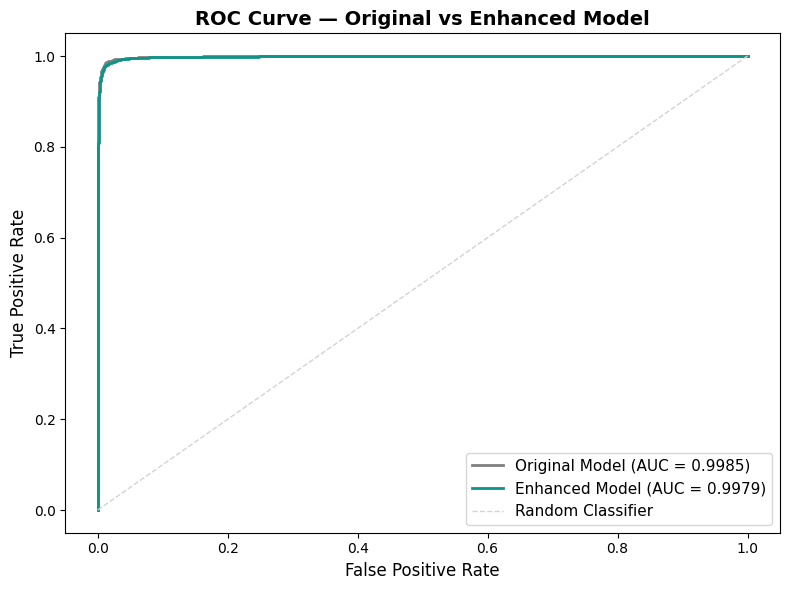

Original AUC: 0.9985
Enhanced AUC: 0.9979
AUC improvement: -0.0006


In [12]:
# Enhanced model ROC
y_test_binary = (y_test == "FAKE").astype(int)
y_prob_fake = y_prob[:, 0]
fpr, tpr, _ = roc_curve(y_test_binary, y_prob_fake)
auc_enhanced = roc_auc_score(y_test_binary, y_prob_fake)

# Load original model for comparison
with open("/content/drive/MyDrive/FactLens_Group9/data/logistic_regression_model.pkl", "rb") as f:
    model_original = pickle.load(f)

X_test_original = sp.load_npz("/content/drive/MyDrive/FactLens_Group9/data/X_test.npz")
y_test_original = pd.read_csv("/content/drive/MyDrive/FactLens_Group9/data/y_test.csv")["label"]
y_prob_original = model_original.predict_proba(X_test_original)
y_test_orig_binary = (y_test_original == "FAKE").astype(int)
fpr_orig, tpr_orig, _ = roc_curve(y_test_orig_binary, y_prob_original[:, 0])
auc_original = roc_auc_score(y_test_orig_binary, y_prob_original[:, 0])

# Plot both
plt.figure(figsize=(8, 6))
plt.plot(fpr_orig, tpr_orig, color="gray", linewidth=2,
         label=f"Original Model (AUC = {auc_original:.4f})")
plt.plot(fpr, tpr, color="#0D9488", linewidth=2,
         label=f"Enhanced Model (AUC = {auc_enhanced:.4f})")
plt.plot([0, 1], [0, 1], color="lightgray", linewidth=1,
         linestyle="--", label="Random Classifier")
plt.title("ROC Curve — Original vs Enhanced Model",
          fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FactLens_Group9/data/roc_comparison.png", dpi=150)
plt.show()

print(f"Original AUC: {auc_original:.4f}")
print(f"Enhanced AUC: {auc_enhanced:.4f}")
print(f"AUC improvement: {auc_enhanced - auc_original:+.4f}")

In [13]:
with open("/content/drive/MyDrive/FactLens_Group9/data/logistic_regression_enhanced.pkl", "wb") as f:
    pickle.dump(model_enhanced, f)

print("Enhanced model saved as logistic_regression_enhanced.pkl")

Enhanced model saved as logistic_regression_enhanced.pkl
